# Compute the mean surface geostrophic velocity at the position of the PF, for each year

### PF position:
from scripts:
- PF_position_clean which computes the probability of presence of Winter Waters
- and PF_position_from_ww_prob_presence which computes the PF as the northernmost limit of WW (80\% probability threshold)

### Mean surface geostrophic currents:
From script average_velocity_field which averages DUACS.

In both cases, the time period is week 25 to week 29+18 weeks of advection (roughly end of June to end of November).

### In this script:
For each year, read both the position of the PF and the mean geostrophic currents.
Extract the currents at the PF location.

To be compared with larval retention rates in the article.

### Last update: September 2026

In [1]:
file_modules="/home/analivaev/Documents/THESE/Scripts/CMIP6/modules/import_modules.py"
with open(file_modules) as file:
    exec(file.read())

/home/analivaev/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
year_list=[str(item) for item in np.arange(2000,2024)]

rep_PF='/home/analivaev/Documents/THESE/Data/Legines/position_PF/'
rep_uv='/home/analivaev/Documents/THESE/Data/Legines/averaged_velocity_fields/New_version_var_PF_position/'

for year in year_list:
    
    file_PF=rep_PF+'position_PF_{}_week_25-29.csv'.format(year)
    df=pd.read_csv(file_PF)
    lon_pf=df['lon_PF']
    lat_pf=df['lat_PF']
    
    file_uv=rep_uv+'{}_uv_norm_field.nc'.format(year)
    
    data_uv=Dataset(file_uv,'r',format='NETCDF4')

    
    lon,lat=data_uv.variables['lon'],data_uv.variables['lat']

    uv_norm=data_uv.variables['Geostrophic velocity field norm']
    
    index_lon_pf_on_duacs_grid,index_lat_pf_on_duacs_grid=[],[]

    for i in range(len(lon_pf)):
        lon_item=lon_pf[i]
        lat_item=lat_pf[i]
    
        ilon=np.searchsorted(lon[:],lon_item)
        ilat=np.searchsorted(lat[:],lat_item)
        index_lon_pf_on_duacs_grid.append(ilon)
        index_lat_pf_on_duacs_grid.append(ilat)
        
    intensity_pf=np.array(uv_norm)[index_lat_pf_on_duacs_grid,index_lon_pf_on_duacs_grid]
        
    df_output=pd.DataFrame(data={'lon_PF':lon_pf,
                             'lat_PF':lat_pf,
                            'surface currents at PF(cm/s)':intensity_pf})

    print(df_output)
    
    df_output.to_csv(rep_PF+'intensity_PF_{}_week_25-29.csv'.format(year))

        lon_PF     lat_PF  surface currents at PF(cm/s)
0    60.958344 -52.013885                      6.600848
1    61.041676 -51.937496                      4.453340
2    61.125010 -51.874996                      5.975841
3    61.208344 -51.822910                      7.282148
4    61.291676 -51.774296                      5.235559
..         ...        ...                           ...
212  78.625040 -52.177002                     13.547714
213  78.708336 -52.204792                     12.669096
214  78.791664 -52.225628                     12.669096
215  78.875040 -52.249958                     13.690213
216  78.958336 -52.270794                     15.089518

[217 rows x 3 columns]
        lon_PF     lat_PF  surface currents at PF(cm/s)
0    60.958344 -53.197918                      7.222756
1    61.041676 -53.173610                      8.619401
2    61.125010 -53.152775                      8.309628
3    61.208344 -53.128468                      7.527389
4    61.291676 -53.10416

        lon_PF     lat_PF  surface currents at PF(cm/s)
0    60.958344 -50.138897                      3.499047
1    61.041676 -50.177094                      3.499047
2    61.125010 -50.218754                      2.778520
3    61.208344 -50.260420                      2.057862
4    61.291676 -50.305560                      2.057862
..         ...        ...                           ...
212  78.625040 -51.434002                     11.909591
213  78.708336 -51.475666                      9.383015
214  78.791664 -51.513874                      9.383015
215  78.875040 -51.552082                      9.547291
216  78.958336 -51.590290                      9.730284

[217 rows x 3 columns]
        lon_PF     lat_PF  surface currents at PF(cm/s)
0    60.958344 -51.430560                      5.489503
1    61.041676 -51.434036                      5.489503
2    61.125010 -51.437510                      1.656197
3    61.208344 -51.444458                      1.330802
4    61.291676 -51.45834

### Previous tests

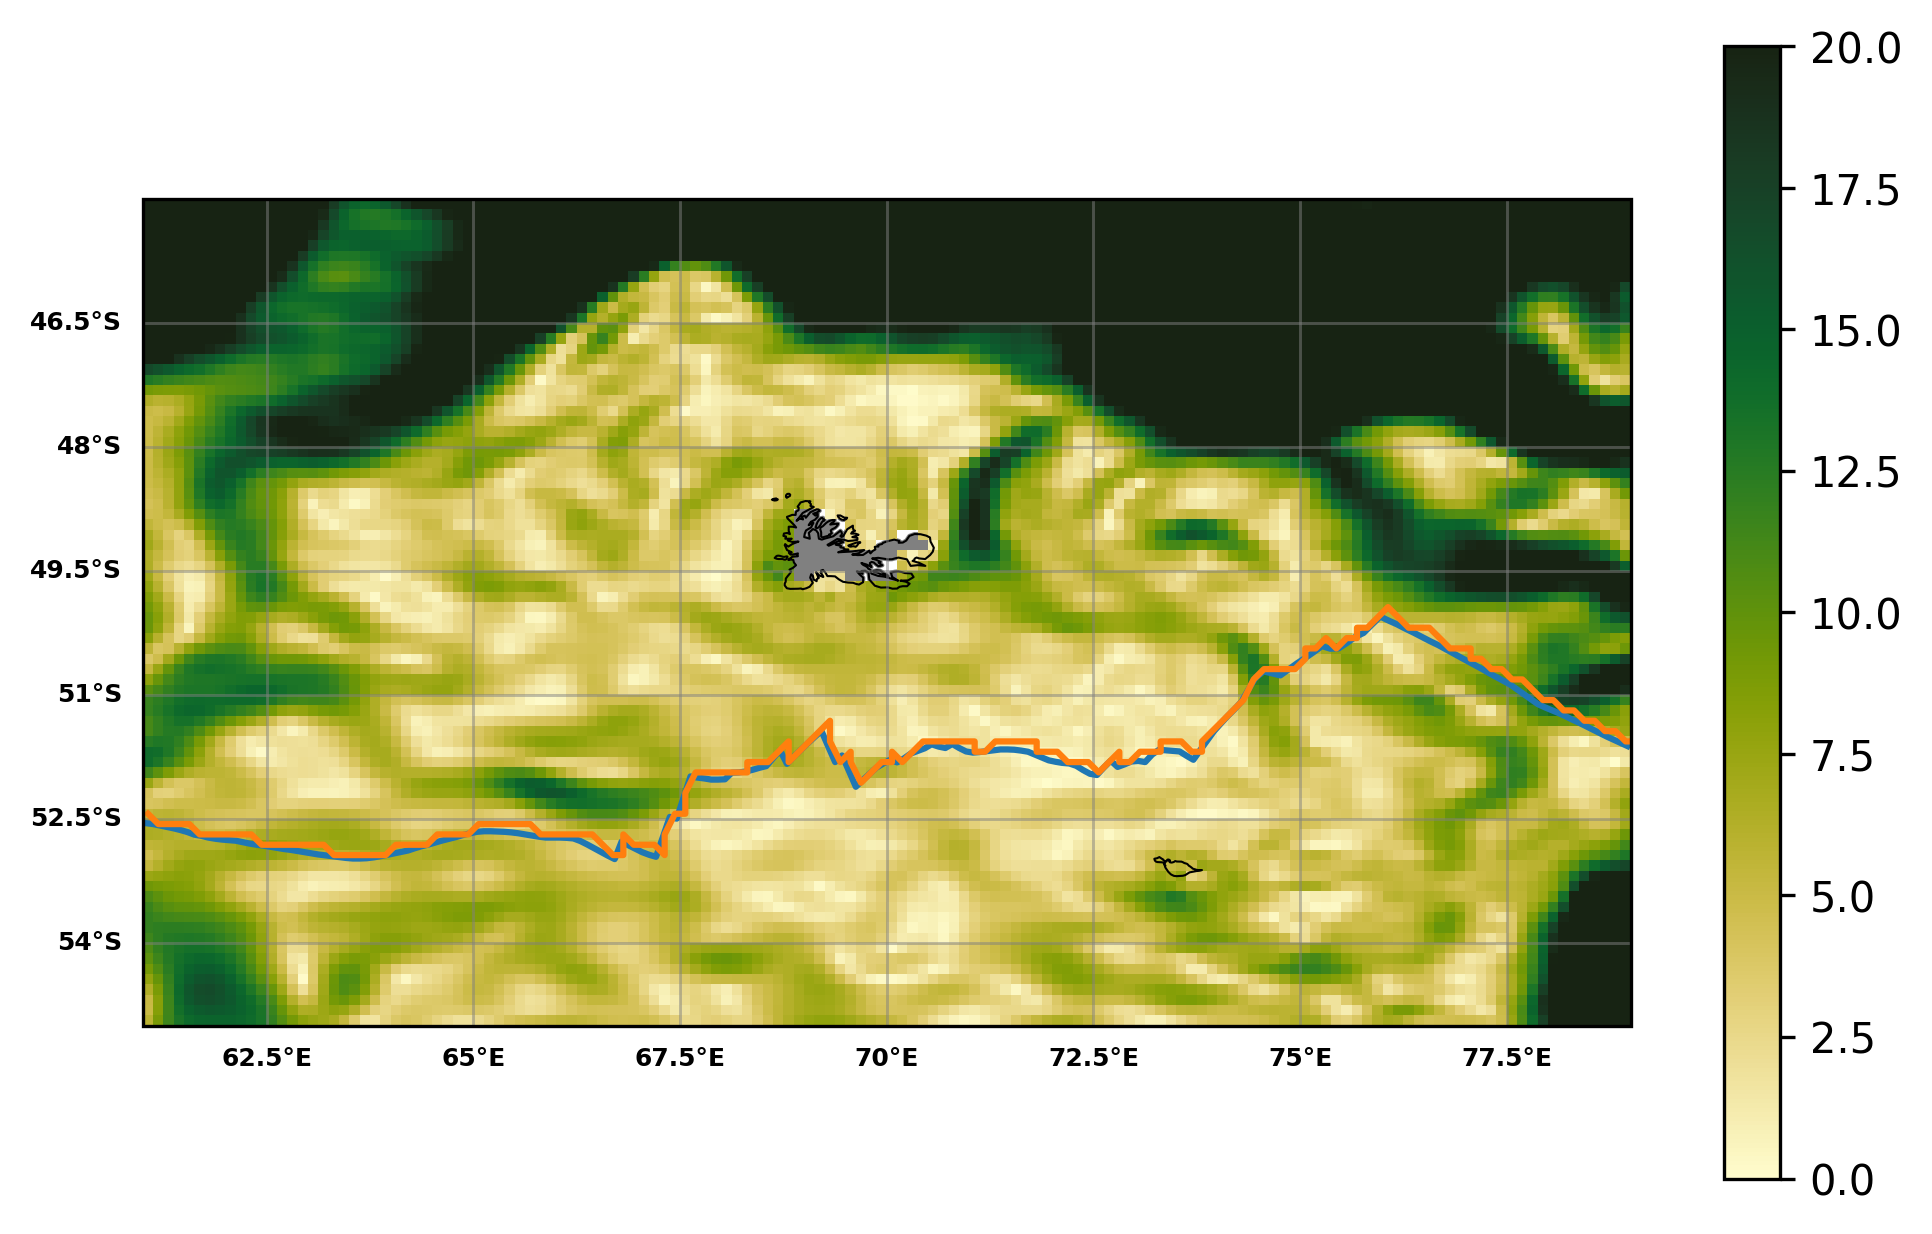

In [3]:
X,Y=np.meshgrid(lon,lat)
req_dpi=300

fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()},figsize=(8,5),dpi=req_dpi)


gl = ax.gridlines(crs=ccrs.PlateCarree(),
                  linewidth=0.7, color='gray', alpha=0.5)

gl.bottom_labels=True
gl.left_labels = True  

gl.xformatter = LONGITUDE_FORMATTER
gl.yformatter = LATITUDE_FORMATTER
gl.ylabel_style = {'size': 6, 'color': 'black','weight':'semibold'}
gl.xlabel_style = {'size':6,'color': 'black', 'weight': 'semibold'}

ax.add_feature(cartopy.feature.LAND,color='grey')
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)

proj = ccrs.PlateCarree(central_longitude=70) # longitude "médiane" de la carte
ax.set_extent([-9,9,-55,-45],crs=proj)

im=ax.pcolormesh(X,Y,uv_norm,transform=ccrs.PlateCarree(),vmin=0,vmax=20,cmap=cmocean.cm.speed)
fig.colorbar(im)

ax.plot(lon_pf,lat_pf,transform=ccrs.PlateCarree())
ax.plot(lon[index_lon_pf_on_duacs_grid],lat[index_lat_pf_on_duacs_grid],transform=ccrs.PlateCarree())

In [4]:
df_output

,lon_PF,lat_PF,surface currents at PF(cm/s)
0,60.958344,-52.545140,5.454272
1,61.041676,-52.552090,5.454272
2,61.125010,-52.562504,6.544816
3,61.208344,-52.579865,6.389261
4,61.291676,-52.597225,6.389261
...,...,...,...
207,78.625000,-51.461914,6.405571
208,78.708336,-51.503582,7.025676
209,78.791664,-51.541748,7.025676
210,78.875000,-51.579914,5.057531
